<a href="https://colab.research.google.com/github/rameshaditya-me/Easy-Classical-ML-DL/blob/main/linear-regression/linear-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression
---

Given data $(x_1, \ldots, x_n)$ with $x_i \in \mathbb{R}^d$ and targets $(y_1, \ldots, y_n)$ with $y_i \in \mathbb{R}^m$, we want a hypothesis $f : \mathcal{X} \to \mathcal{Y}$ that maps an input $x$ to a prediction $f(x)$.

Regression models have continuous outputs $y \in \mathbb{R}^m$. We assume the hypothesis is linear in the parameters:

$$
f(x) = W^\top x, \quad W \in \mathbb{R}^{d \times m},
$$

so $y$ is a linear function of $W$. The inputs may enter through basis functions $\phi(x)$; replacing $x$ with $\phi(x)$ gives a generalized linear model.

---

The model above is deterministic: each $x$ maps to a single $f(x)$. In practice, observations are noisy and are modelled as

$$
y_i = f(x_i) + \epsilon_i, \quad i = 1, \ldots, n \tag{1}
$$

where the errors $\epsilon_i$ are i.i.d. $\mathcal{N}(0, \sigma^2)$ and independent of $x_i$. Equivalently we can say that **conditioned on the independent variable $x_i$**, $y_i \mid x_i \sim \mathcal{N}(f(x_i), \sigma^2)$.

When $f$ is the true generating function, the **error** is $\epsilon_i = y_i - f(x_i)$. After fitting $\hat{f}$, the **residual** is $e_i = y_i - \hat{f}(x_i)$; if $\hat{f} = f$, then $e_i = \epsilon_i$. From the noise model, the true errors satisfy:

1. **Homoscedasticity:** $\mathrm{Var}(\epsilon_i \mid x_i) = \sigma^2$ for all $i$ (constant variance).
2. **Independence:** $\epsilon_i$ and $\epsilon_j$ are independent for $i \neq j$.
3. **Normality:** $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$.

These properties are often checked on residuals $e_i$ after fitting.

A separate assumption concerns the design matrix $X \in \mathbb{R}^{n \times d}$, whose rows are $x_i^\top$:

4. **No multicollinearity:** $\mathrm{rank}(X) = d$ (full column rank), i.e. no feature column is a linear combination of the others. If this were not the case we would have redundant features.

---

Given a dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$, stack the inputs into a design matrix $X \in \mathbb{R}^{n \times d}$ (rows $x_i^\top$) and targets into $Y \in \mathbb{R}^{n \times m}$ (rows $y_i^\top$). The linear model in matrix form is

$$
Y = XW,
$$

equivalently $y_i = W^\top x_i$ for each $i$. The residual for observation $i$ is $e_i = y_i - W^\top x_i$. The joint likelihood of the errors is

$$
p(e_1, \ldots, e_n) = \prod_{i=1}^n p(e_i) = \prod_{i=1}^n \mathcal{N}(y_i - W^\top x_i, \sigma^2).
$$

Taking the negative log-likelihood,

$$
-\log p(e_1, \ldots, e_n) = \sum_{i=1}^n \frac{\|y_i - W^\top x_i\|_2^2}{2\sigma^2} + K.
$$

For the maximum likelihood estimate, differentiate the sum of squared errors:

$$
\nabla_W \sum_{i=1}^n \|y_i - W^\top x_i\|_2^2 = \nabla_W \sum_{i=1}^n (y_i - W^\top x_i)^\top (y_i - W^\top x_i) = \nabla_W \sum_{i=1}^n (y_i^\top - x_i^\top W)(y_i - W^\top x_i)
$$

$$
\nabla_W \sum_{i=1}^n \bigl(y_i^\top y_i - y_i^\top W^\top x_i - x_i^\top W y_i + x_i^\top W W^\top x_i\bigr) = \sum_{i=1}^n \bigl(-x_i y_i^\top - x_i y_i^\top + 2 x_i x_i^\top W\bigr)
$$

Setting the gradient to zero and cancelling the factor of 2,

$$
\sum_{i=1}^n x_i y_i^\top = \sum_{i=1}^n x_i x_i^\top W \quad \Rightarrow \quad X^\top Y = X^\top X W \quad \Rightarrow \quad W = (X^\top X)^{-1} X^\top Y.
$$

Here, this estimate of $W$ is called the OLS or Ordinary Least Square estimate. For the term $(X^TX)$ to be invertible No multi-collinearity is a necessary condition.

If $n \times d$ is very large, storing $X$ in memory at once can become costly. We can instead minimize the same objective with gradient descent. The likelihood and normality of the residuals give a loss to minimize: the mean squared error between targets and predictions,

$$
\mathcal{L}(W) = \frac{1}{n}\sum_{i=1}^n \|y_i - W^\top x_i\|_2^2 = \frac{1}{n}\|Y - XW\|_F^2.
$$

**Batch gradient descent** updates all of $W$ using the full dataset:

$$
W^{t+1} = W^t - \eta \, \nabla_W \mathcal{L},
\qquad
\nabla_W \mathcal{L} = \frac{2}{n} X^\top (XW - Y).
$$

**Stochastic gradient descent (SGD)** uses one sample $(x_i, y_i)$ per step with $\nabla_W \|y_i - W^\top x_i\|^2 = 2 x_i (W^\top x_i - y_i)^\top$ (noisier but cheaper per iteration).

**Learning rate $\eta$.** The step size controls how far we move along the negative gradient. If $\eta$ is too large, updates overshoot and the loss can oscillate or diverge; if $\eta$ is too small, convergence is slow. For this quadratic loss, stability roughly requires $\eta < 2 / \lambda_{\max}$, where $\lambda_{\max}$ is the largest eigenvalue of the Hessian $\nabla_W^2 \mathcal{L} = \frac{2}{n} X^\top X$. In practice $\eta$ is tuned (fixed schedule, decay, or line search).

**Feature scaling.** Gradient descent is sensitive to the scale of the columns of $X$: a feature with large magnitude contributes more to $X^\top X$ and yields a steeper direction in $W$, so one coordinate of $W$ can update much faster than another. Standardizing or normalizing features (zero mean, unit variance) often makes optimization more stable. The closed-form OLS solution $\hat{W} = (X^\top X)^{-1} X^\top Y$ **reweights** features through $(X^\top X)^{-1}$, so coefficient estimates change under rescaling—but **predictions** $\hat{y} = X \hat{W}$ are unchanged if each column $x^{(j)}$ is scaled by $c_j$ and the corresponding weights are scaled by $1/c_j$. SGD does not apply that reweighting automatically; without scaling, it may converge slowly even when OLS would give the same fit in one solve.

**Convexity.** $\mathcal{L}(W)$ is a convex function of $W$ (a sum of convex quadratics in $W$). Its Hessian $\frac{2}{n} X^\top X$ is positive semidefinite; if $X$ has full column rank, $\mathcal{L}$ is strictly convex and has a **unique** minimizer. Batch gradient descent with a suitable $\eta$ therefore converges to the same $\hat{W}$ as OLS (up to numerical error). SGD converges in expectation under standard step-size schedules, but individual runs fluctuate around the minimum because of mini-batch noise.

# Properties of the OLS Estimator
---

For a fixed design matrix $X$, $\hat{W} = (X^\top X)^{-1} X^\top Y$. On a new sample from the same model we get a different $\hat{W}'$; we analyze bias and variance **conditional on $X$**.

Assume $Y = X W_\star + \varepsilon$ with $\mathbb{E}[\varepsilon \mid X] = 0$ and $\mathbb{E}[\varepsilon \varepsilon^\top \mid X] = \sigma^2 I_n$ (scalar noise; matrix case analogous).

### 1. Unbiasedness

$$
\hat{W} = (X^\top X)^{-1} X^\top (X W_\star + \varepsilon) = W_\star + (X^\top X)^{-1} X^\top \varepsilon.
$$

Therefore

$$
\mathbb{E}[\hat{W} \mid X] = W_\star.
$$

### 2. Variance (covariance)

From unbiasedness, $\hat{W} - W_\star = (X^\top X)^{-1} X^\top \varepsilon$. For a vector/matrix estimator, use the **covariance** (not $\mathbb{E}[\hat{W}^2] - \mathbb{E}[\hat{W}]^2$ elementwise):

$$
\mathrm{Cov}(\hat{W} \mid X) = \mathbb{E}\bigl[(\hat{W} - W_\star)(\hat{W} - W_\star)^\top \mid X\bigr].
$$

**Scalar case ($m = 1$).** Write $\hat{w} = w_\star + (X^\top X)^{-1} X^\top \varepsilon$. Then

$$
\mathrm{Cov}(\hat{w} \mid X) = (X^\top X)^{-1} X^\top \, \mathbb{E}[\varepsilon \varepsilon^\top \mid X] \, X (X^\top X)^{-1}.
$$

With $\mathbb{E}[\varepsilon \mid X] = 0$ and $\mathbb{E}[\varepsilon \varepsilon^\top \mid X] = \sigma^2 I_n$,

$$
\boxed{\mathrm{Cov}(\hat{w} \mid X) = \sigma^2 (X^\top X)^{-1}}.
$$

*Finishing your expansion.* Substitute $Y = X w_\star + \varepsilon$ into $\hat{w} = (X^\top X)^{-1} X^\top Y$, so only $\varepsilon$ remains in $\hat{w} - w_\star$. Cross-terms vanish when taking $\mathbb{E}[\cdot \mid X]$ because $\mathbb{E}[\varepsilon \mid X] = 0$. The surviving term is

$$
(X^\top X)^{-1} X^\top \varepsilon \varepsilon^\top X (X^\top X)^{-1},
$$

which gives $\sigma^2 (X^\top X)^{-1}$ after expectation. Note $(X^\top X)^{-1}$ appears **once** here; an extra $(X^\top X)^{-1}$ in the middle of the expansion is a common slip.

**Matrix case ($m > 1$).** Each column satisfies $\mathrm{Cov}(\hat{w}^{(j)} \mid X) = \sigma^2 (X^\top X)^{-1}$.

### 3. Gauss–Markov (BLUE)

Among all **linear unbiased** estimators of $w_\star$, OLS has minimum variance (smallest covariance in the Loewner order). The matrix case $\hat{W}$ is analogous.

**Step 1 — Characterize linear unbiased estimators.** Any linear estimator has the form $\tilde{w} = C y$ with $C \in \mathbb{R}^{d \times n}$. Under $y = X w_\star + \varepsilon$ and $\mathbb{E}[\varepsilon \mid X] = 0$,

$$
\mathbb{E}[\tilde{w} \mid X] = C X w_\star.
$$

Unbiasedness ($\mathbb{E}[\tilde{w} \mid X] = w_\star$ for all $w_\star$) requires

$$
C X = I_d.
$$

**Step 2 — Every such estimator is OLS plus extra noise.** Write $C = (X^\top X)^{-1} X^\top + D$. Then $C X = I_d + D X$, so unbiasedness forces $D X = 0$. Substituting into $\tilde{w} = C y$:

$$
\tilde{w} = (X^\top X)^{-1} X^\top (X w_\star + \varepsilon) + D (X w_\star + \varepsilon) = w_\star + (X^\top X)^{-1} X^\top \varepsilon + D \varepsilon.
$$

The first noise term is the OLS fluctuation; $D \varepsilon$ is an extra contribution (and $D X w_\star = 0$ removes $w_\star$ from the $D$ term).

**Step 3 — Compare covariances.** With $\mathrm{Cov}(\varepsilon \mid X) = \sigma^2 I_n$ and $D X = 0$,

$$
\mathrm{Cov}(\tilde{w} \mid X) = \sigma^2 \bigl[(X^\top X)^{-1} X^\top + D\bigr]\bigl[(X^\top X)^{-1} X^\top + D\bigr]^\top = \sigma^2 \bigl[(X^\top X)^{-1} + D D^\top\bigr].
$$

OLS gives $\mathrm{Cov}(\hat{w} \mid X) = \sigma^2 (X^\top X)^{-1}$. Hence

$$
\mathrm{Cov}(\tilde{w} \mid X) - \mathrm{Cov}(\hat{w} \mid X) = \sigma^2 D D^\top \succeq 0.
$$

So $\mathrm{Var}(a^\top \tilde{w} \mid X) \ge \mathrm{Var}(a^\top \hat{w} \mid X)$ for every $a \in \mathbb{R}^d$: OLS is **BLUE** (Best Linear Unbiased Estimator).

> **Scope:** This does not require normality of $\varepsilon$. It does not compare to nonlinear or biased estimators (e.g. ridge can have lower MSE by trading bias for variance).

### 4. Estimating $\sigma^2$

With residuals $e = Y - X \hat{W}$, an unbiased estimator is $\hat{\sigma}^2 = \frac{1}{n - d} \|e\|_F^2$ when $\mathrm{rank}(X) = d$.

# Appendix
---

### A. Why the step size condition is $0 < \eta < \frac{2}{\lambda_{\max}}$

For

$$
\mathcal{L}(W)=\frac{1}{n}\|Y-XW\|_F^2,
$$

the gradient is

$$
\nabla_W\mathcal{L}=\frac{2}{n}X^\top(XW-Y).
$$

Let $W_\star$ be the minimizer (OLS solution), so $X^\top(XW_\star-Y)=0$. Define the error matrix $E_t=W_t-W_\star$. Under batch gradient descent,

$$
W_{t+1}=W_t-\eta\frac{2}{n}X^\top(XW_t-Y)
$$

$$
W_{t+1}-W_\star=W_t-W_\star-\eta\frac{2}{n}X^\top(XW_t-Y).
$$

Add and subtract $XW_\star$ inside the gradient term. Since $X^\top(XW_\star-Y)=0$ at the minimizer,

$$
X^\top(XW_t-Y)=X^\top X(W_t-W_\star)=X^\top X E_t.
$$

Therefore

$$
E_{t+1}=\Bigl(I-\eta H\Bigr)E_t,
\qquad H:=\frac{2}{n}X^\top X.
$$

The object that governs convergence is the **iteration matrix** $M := I - \eta H$, not $H$ alone. If $H u_j = \lambda_j u_j$, then

$$
M u_j = (I - \eta H) u_j = (1 - \eta \lambda_j) u_j,
$$

so $u_j$ is also an eigenvector of $M$ with eigenvalue $\mu_j = 1 - \eta \lambda_j$. (More generally, any matrix polynomial in $H$ shares the same eigenvectors as $H$; here $M$ is the affine map $H \mapsto I - \eta H$.)

> **Note:** $X^\top X$ is positive semidefinite for any $X$. For any $v \in \mathbb{R}^d$, let $t = Xv$. Then
> $$
> v^\top X^\top X v = (Xv)^\top (Xv) = t^\top t = \|Xv\|_2^2 \geq 0.
> $$

Since $H$ is symmetric positive semidefinite, $0 \le \lambda_1 \le \cdots \le \lambda_{\max}$. Decompose the error in the eigenbasis of $H$ (equivalently of $M$):

$$
E_t = \sum_j a_t^{(j)} u_j.
$$

Along eigen-direction $u_j$, one GD step multiplies the coefficient by $\mu_j$:

$$
a_{t+1}^{(j)} = \mu_j a_t^{(j)} = (1 - \eta \lambda_j) a_t^{(j)}.
$$

For this mode to contract, we need $|1-\eta\lambda_j|<1$, i.e.

$$
0<\eta<\frac{2}{\lambda_j}.
$$

To contract all modes simultaneously, enforce the strictest condition:

$$
\boxed{0<\eta<\frac{2}{\lambda_{\max}}}.
$$

At $\eta=2/\lambda_{\max}$ the largest-curvature mode oscillates, and for larger $\eta$ it diverges.

### B. Convexity discussion

The MSE objective is quadratic in $W$:

$$
\mathcal{L}(W)=\frac{1}{n}\|Y-XW\|_F^2.
$$

Its Hessian is constant:

$$
\nabla_W^2\mathcal{L}=\frac{2}{n}X^\top X=H\succeq0,
$$

so $\mathcal{L}$ is convex. Consequences:

- Every local minimum is a global minimum.
- If $\mathrm{rank}(X)=d$, then $X^\top X\succ0$, so $\mathcal{L}$ is **strictly convex** and the minimizer is unique.
- If $\mathrm{rank}(X)<d$, the problem is still convex but not strictly convex: there are infinitely many minimizers (same predictions, different coefficients).

Therefore, with full column rank and a stable step size, batch gradient descent converges to the same unique solution as OLS.

Now we will use real life datasets to validate the above properties of linear regression. In this regard we will use 2 datasets from "sklearn.datasets" the california_housing and the diabetes datasets. The california housing has 20640 datapoints and corresponding scalar targets with 8 predictors. The diabetes dataset has 442 data points with 10 predictors.

In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
housing = fetch_california_housing()
print("Num Datapoints: ", housing.data.shape[0], ", Num Predictors: ",housing.data.shape[1], ", Target: ", housing.target.shape[0])
print(housing.feature_names)

Num Datapoints:  20640 , Num Predictors:  8 , Target:  20640
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [3]:
diabetes = load_diabetes()
print("Target: ", diabetes.target.shape)
print("Data: ", diabetes.data.shape)

Target:  (442,)
Data:  (442, 10)


Let us know first visualize both the datasets to get an intuition of each dataset. A first step towards is to quantitatively analyze the statistics for each predictor.

In [4]:


def visualize_data_statistics(
    data: np.ndarray,
    targets: np.ndarray,
    column_names: list[str] | None = None,
    target_name: str = "Target",
    title: str = "Distribution of features and target",
    figsize: tuple[float, float] = (8, 8),
    palette: str = "colorblind",
    show_points: bool = True,
    point_alpha: float = 0.35,
    save_path: str | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """
    box plots of per-column statistics (min, Q25, median, Q75, max)
    for features (top) and target(s) (bottom).

    Parameters
    ----------
    data : np.ndarray
        2D array of shape (n_samples, n_features).
    targets : np.ndarray
        1D array (n_samples,) or 2D array (n_samples, n_targets).
    column_names : list[str] | None
        Feature names for the x-axis.
    target_name : str
        Label for a single target, or prefix if multiple targets.
    title : str
        Overall figure title.
    figsize : tuple
        Figure size in inches.
    palette : str
        Seaborn palette name.
    show_points : bool
        Overlay jittered sample points.
    point_alpha : float
        Alpha for overlaid points.
    save_path : str | None
        If provided, saves a high-resolution figure (PDF/PNG/SVG).

    Returns
    -------
    fig, axes
        Figure and array of axes [ax_features, ax_targets].
    """
    if data.ndim != 2:
        raise ValueError(f"`data` must be 2D, got shape {data.shape}")

    targets = np.asarray(targets)
    if targets.ndim == 1:
        targets = targets.reshape(-1, 1)
    elif targets.ndim != 2:
        raise ValueError(f"`targets` must be 1D or 2D, got shape {targets.shape}")

    if data.shape[0] != targets.shape[0]:
        raise ValueError(
            f"data and targets must have same number of rows; "
            f"got {data.shape[0]} and {targets.shape[0]}"
        )

    n_cols = data.shape[1]
    n_targets = targets.shape[1]

    if column_names is None:
        column_names = [f"Feature {j + 1}" for j in range(n_cols)]
    elif len(column_names) != n_cols:
        raise ValueError("len(column_names) must match number of columns")

    if n_targets == 1:
        target_names = [target_name]
    else:
        target_names = [f"{target_name} {j + 1}" for j in range(n_targets)]

    # Long format
    df_features = pd.DataFrame(data, columns=column_names).melt(
        var_name="Feature", value_name="Value"
    )
    df_targets = pd.DataFrame(targets, columns=target_names).melt(
        var_name="Feature", value_name="Value"
    )

    sns.set_theme(
        style="ticks",
        context="paper",
        font_scale=1.15,
        rc={
            "axes.linewidth": 0.8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        },
    )

    feature_colors = sns.color_palette(palette, n_colors=n_cols)
    target_colors = sns.color_palette(palette, n_colors=n_targets)

    fig, axes = plt.subplots(2, 1, figsize=figsize, dpi=150, sharex=False)
    ax_features, ax_targets = axes

    def _boxplot_panel(ax, df_long, names, colors, ylabel, panel_title):
        sns.boxplot(
            data=df_long,
            x="Feature",
            y="Value",
            hue="Feature",
            order=names,
            hue_order=names,
            palette=colors,
            legend=False,
            width=0.55,
            linewidth=1.0,
            fliersize=0,
            whis=(0, 100),
            ax=ax,
        )
        if show_points:
            sns.stripplot(
                data=df_long,
                x="Feature",
                y="Value",
                order=names,
                color="0.25",
                size=2.5,
                alpha=point_alpha,
                jitter=0.25,
                ax=ax,
                zorder=0,
            )
        ax.set_title(panel_title, pad=10, weight="semibold", fontsize=11)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        sns.despine(ax=ax, trim=True)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    _boxplot_panel(
        ax_features, df_features, column_names, feature_colors,
        ylabel="Value", panel_title="Features"
    )
    _boxplot_panel(
        ax_targets, df_targets, target_names, target_colors,
        ylabel="Value", panel_title="Target(s)"
    )

    fig.suptitle(title, y=1.02, weight="semibold", fontsize=13)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    return fig, axes

In [5]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

(<Figure size 1200x1200 with 2 Axes>,
 array([<Axes: title={'center': 'Features'}, ylabel='Value'>,
        <Axes: title={'center': 'Target(s)'}, ylabel='Value'>],
       dtype=object))

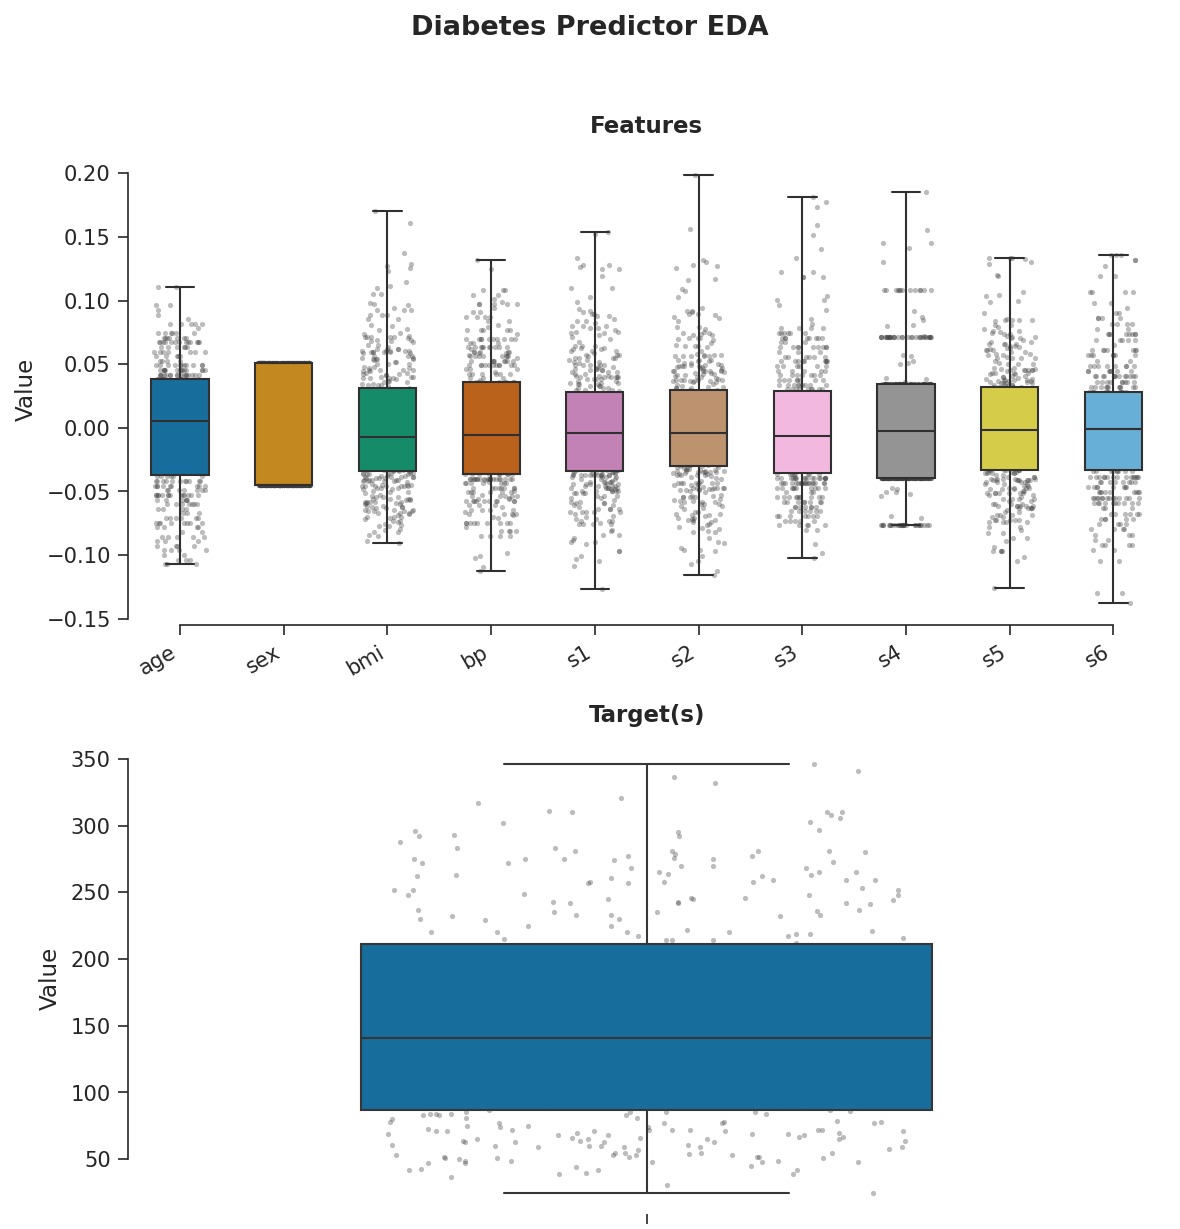

In [6]:
visualize_data_statistics(data=diabetes.data, targets=diabetes.target, target_name="", column_names=diabetes.feature_names, title="Diabetes Predictor EDA")

In [7]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

(<Figure size 1200x1200 with 2 Axes>,
 array([<Axes: title={'center': 'Features'}, ylabel='Value'>,
        <Axes: title={'center': 'Target(s)'}, ylabel='Value'>],
       dtype=object))

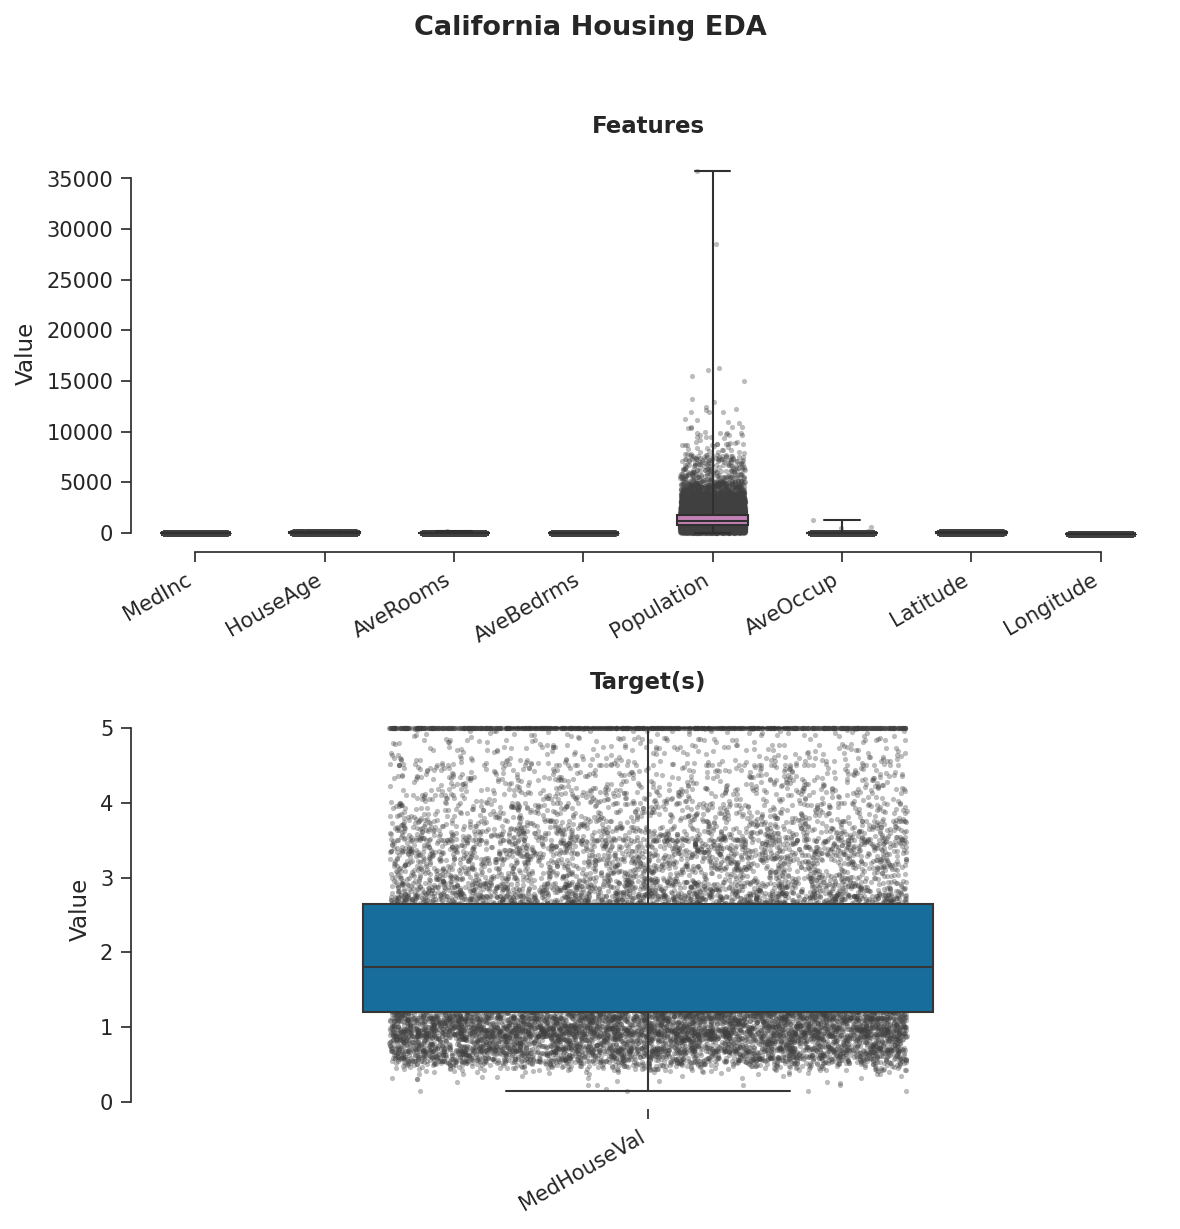

In [8]:
visualize_data_statistics(data=housing.data, targets=housing.target, target_name=housing.target_names[0], column_names=housing.feature_names, title="California Housing EDA")

As we can see from the predictor wise box-plot, for diabetes dataset the features seem well centred and having similar scale (apart from the sex feature which is discrete) and for the housing dataset population has a dissproportionately large scale compared to the rest of the features.

Next, we will perform an OLS fit using the predictors and check the mean square error between the targets and the predicted targets. For this we need to split the data into a train and test dataset. We will follow a 75-25 split for the train and test datasets.

In [9]:
def split_data(data: np.array, predictors: np.array):
  X_train, X_test, y_train, y_test = train_test_split(
    data, predictors, test_size=0.25, random_state=42)
  return X_train, X_test, y_train, y_test

In [10]:
housing_train, housing_test, housing_target_train, housing_target_test = split_data(housing.data, housing.target)
print(f"Train Data Size: {housing_train.shape}", f", Train Predictor Size: {housing_target_train.shape}")
print(f"Test Data Size: {housing_test.shape}", f", Test Predictor Size: {housing_target_test.shape}")

Train Data Size: (15480, 8) , Train Predictor Size: (15480,)
Test Data Size: (5160, 8) , Test Predictor Size: (5160,)


In [11]:
diabetes_train, diabetes_test, diabetes_target_train, diabetes_target_test = split_data(diabetes.data, diabetes.target)
print(f"Train Data Size: {diabetes_train.shape}", f", Train Predictor Size: {diabetes_target_train.shape}")
print(f"Test Data Size: {diabetes_test.shape}", f", Test Predictor Size: {diabetes_target_test.shape}")

Train Data Size: (331, 10) , Train Predictor Size: (331,)
Test Data Size: (111, 10) , Test Predictor Size: (111,)


In [12]:
def fit_ols_predictor(X: np.ndarray, Y: np.ndarray):
    X = np.asarray(X)
    Y = np.asarray(Y)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D (n_samples, n_features); got shape {X.shape}")
    if Y.ndim != 2:
        raise ValueError(f"Y must be 2D (n_samples, n_targets); got shape {Y.shape}")

    n_x, d = X.shape
    n_y, m = Y.shape

    if n_x != n_y:
        raise ValueError(
            f"X and Y must have the same number of rows; got X.shape[0]={n_x}, Y.shape[0]={n_y}"
        )
    if n_x == 0:
        raise ValueError("X and Y must have at least one sample")

    n = n_x

    W = np.linalg.inv(X.T@X)@X.T@Y
    print(f"Fitted OLS Weight Vector is of dimension: {W.shape}")
    return W

In [13]:
W_housing_ols = fit_ols_predictor(housing_train, np.expand_dims(housing_target_train, axis=1))

Fitted OLS Weight Vector is of dimension: (8, 1)


In [14]:
W_diabetes_ols = fit_ols_predictor(diabetes_train, np.expand_dims(diabetes_target_train, axis=1))

Fitted OLS Weight Vector is of dimension: (10, 1)


In [15]:
pred_targets_housing = housing_test@W_housing_ols
pred_targets_diabetes = diabetes_test@W_diabetes_ols

In [16]:
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return np.mean((y_true - y_pred) ** 2)
def nmse_by_variance(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """NMSE = MSE / Var(y_true). Common in regression."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return mse(y_true, y_pred) / np.var(y_true, ddof=0)
def nmse_by_norm(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """NMSE = ||y - y_hat||^2 / ||y||^2."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)

In [17]:
print(f"MSE for housing dataset is: {mse(housing_target_test, pred_targets_housing)}")
print(f"MSE for diabetes dataset is: {mse(diabetes_target_test, pred_targets_diabetes)}")
print(f"Normalized MSE for housing dataset is: {nmse_by_variance(housing_target_test, pred_targets_housing)}")
print(f"Normalized MSE for diabetes dataset is: {nmse_by_variance(diabetes_target_test, pred_targets_diabetes)}")


MSE for housing dataset is: 0.6159307296888458
MSE for diabetes dataset is: 27317.164972981667
Normalized MSE for housing dataset is: 0.4654793698800608
Normalized MSE for diabetes dataset is: 4.94008994561072


Here we can see that there is an extremely large MSE and Normalized MSE for the diabetes dataset even though the data looks centred. This mainly due to a lack of an intercept term. Without an intercept term we always assume that the line passes through the origin even though the data might not actually be centred at the origin.

Thus, we need to slightly modify the OLS regression model by adding an intercept term or by subtracting the mean from the data.

In [18]:
def fit_ols_predictor_with_intercept(X: np.ndarray, Y: np.ndarray):
    X = np.asarray(X)
    Y = np.asarray(Y)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D (n_samples, n_features); got shape {X.shape}")
    if Y.ndim != 2:
        raise ValueError(f"Y must be 2D (n_samples, n_targets); got shape {Y.shape}")

    n_x, d = X.shape
    n_y, m = Y.shape

    if n_x != n_y:
        raise ValueError(
            f"X and Y must have the same number of rows; got X.shape[0]={n_x}, Y.shape[0]={n_y}"
        )
    if n_x == 0:
        raise ValueError("X and Y must have at least one sample")

    n = n_x
    X = np.hstack((X, np.ones((n,1))))
    print(f"X with intercept is of size: {X.shape}")
    W = np.linalg.inv(X.T@X)@X.T@Y
    print(f"Fitted OLS Weight Vector is of dimension: {W.shape}")
    return W

In [19]:
W_housing_ols_with_intercept = fit_ols_predictor_with_intercept(housing_train, np.expand_dims(housing_target_train, axis=1))
W_diabetes_ols_with_intercept = fit_ols_predictor_with_intercept(diabetes_train, np.expand_dims(diabetes_target_train, axis=1))

X with intercept is of size: (15480, 9)
Fitted OLS Weight Vector is of dimension: (9, 1)
X with intercept is of size: (331, 11)
Fitted OLS Weight Vector is of dimension: (11, 1)


In [20]:
housing_test = np.hstack((housing_test, np.ones((housing_test.shape[0],1))))
diabetes_test = np.hstack((diabetes_test, np.ones((diabetes_test.shape[0],1))))

In [21]:
pred_targets_housing = housing_test@W_housing_ols_with_intercept
pred_targets_diabetes = diabetes_test@W_diabetes_ols_with_intercept

In [22]:
print(f"MSE for housing dataset is: {mse(housing_target_test, pred_targets_housing)}")
print(f"MSE for diabetes dataset is: {mse(diabetes_target_test, pred_targets_diabetes)}")
print(f"Normalized MSE for housing dataset is: {nmse_by_variance(housing_target_test, pred_targets_housing)}")
print(f"Normalized MSE for diabetes dataset is: {nmse_by_variance(diabetes_target_test, pred_targets_diabetes)}")

MSE for housing dataset is: 0.5411287478474699
MSE for diabetes dataset is: 2848.310650847535
Normalized MSE for housing dataset is: 0.40894902045116793
Normalized MSE for diabetes dataset is: 0.5150941110523297


Now we can see that compared to our previous results the MSE and NMSE for diabetes has significantly dropped and the housing MSE and NMSE have also improved significantly. Let us now try pre processing and centering our data prior to fitting the OLS model.

In [23]:
housing = fetch_california_housing()
diabetes = load_diabetes()
housing_scaler = StandardScaler()
housing_target_scaler = StandardScaler()
diabetes_scaler = StandardScaler()
diabetes_target_scaler = StandardScaler()

housing_train, housing_test, housing_target_train, housing_target_test = split_data(housing.data, housing.target)
diabetes_train, diabetes_test, diabetes_target_train, diabetes_target_test = split_data(diabetes.data, diabetes.target)

housing_target_train = np.expand_dims(housing_target_train, axis=-1)
diabetes_target_train = np.expand_dims(diabetes_target_train, axis=-1)

housing_scaler.fit(housing_train)
housing_target_scaler.fit(housing_target_train)
diabetes_scaler.fit(diabetes_train)
diabetes_target_scaler.fit(diabetes_target_train)

housing_train = housing_scaler.transform(housing_train)
housing_test = housing_scaler.transform(housing_test)

housing_target_train = housing_target_scaler.transform(housing_target_train)
housing_target_test = housing_target_scaler.transform(np.expand_dims(housing_target_test, axis=-1))

diabetes_train = diabetes_scaler.transform(diabetes_train)
diabetes_test = diabetes_scaler.transform(diabetes_test)

diabetes_target_train = diabetes_target_scaler.transform(diabetes_target_train)
diabetes_target_test = diabetes_target_scaler.transform(np.expand_dims(diabetes_target_test, axis=-1))

In [24]:
W_housing_ols_with_intercept = fit_ols_predictor_with_intercept(housing_train, housing_target_train)
W_diabetes_ols_with_intercept = fit_ols_predictor_with_intercept(diabetes_train, diabetes_target_train)

X with intercept is of size: (15480, 9)
Fitted OLS Weight Vector is of dimension: (9, 1)
X with intercept is of size: (331, 11)
Fitted OLS Weight Vector is of dimension: (11, 1)


In [25]:
housing_test = np.hstack((housing_test, np.ones((housing_test.shape[0],1))))
diabetes_test = np.hstack((diabetes_test, np.ones((diabetes_test.shape[0],1))))
pred_targets_housing = housing_test@W_housing_ols_with_intercept
pred_targets_diabetes = diabetes_test@W_diabetes_ols_with_intercept

In [26]:
print(f"MSE for housing dataset is: {mse(housing_target_test, pred_targets_housing)}")
print(f"MSE for diabetes dataset is: {mse(diabetes_target_test, pred_targets_diabetes)}")
print(f"Normalized MSE for housing dataset is: {nmse_by_variance(housing_target_test, pred_targets_housing)}")
print(f"Normalized MSE for diabetes dataset is: {nmse_by_variance(diabetes_target_test, pred_targets_diabetes)}")

MSE for housing dataset is: 0.4055480153020336
MSE for diabetes dataset is: 0.4712138217138828
Normalized MSE for housing dataset is: 0.40894902045086484
Normalized MSE for diabetes dataset is: 0.5150941110523236


Now, we will move to the SGD version of linear regression model.

In [61]:
def grad(X: np.ndarray, Y: np.ndarray, W: np.ndarray):
  return X.T@(X@W-Y)

def step(X: np.ndarray, Y: np.ndarray, W: np.ndarray, lr: np.ndarray):
  W = W - lr*grad(X=X,Y=Y,W=W)
  return W

def train(X: np.ndarray, Y:np.ndarray, lr:np.ndarray, num_epochs: int):
  n = X.shape[0]
  d = X.shape[1]
  m = Y.shape[1]
  X = np.hstack((X,np.ones((n,1))))
  train_loss = np.zeros(num_epochs*n)
  idx = 0
  W = np.random.randn(d+1,m)
  for epochs in range(num_epochs):
    for sample in range(n):
      loss = mse(Y, X@W)
      train_loss[idx]=loss
      idx+=1
      W = step(np.expand_dims(X[sample,:], axis=0),np.expand_dims(Y[sample,:],axis=0),W,lr)
  return W, train_loss

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def visualize_train_loss(
    train_loss: np.ndarray,
    lr: float | None = None,
    ols_mse: float | None = None,
    title: str = "Training loss vs step",
    figsize: tuple[float, float] = (8.5, 5),
    log_y: bool = False,
    smooth_window: int | None = 50,
    show_epoch_avg: bool = True,
    n_samples: int | None = None,
    save_path: str | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    train_loss = np.asarray(train_loss).ravel()
    steps = np.arange(1, len(train_loss) + 1)

    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.15,
        rc={
            "axes.linewidth": 0.8,
            "grid.linewidth": 0.6,
            "grid.alpha": 0.35,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "legend.frameon": False,
        },
    )

    palette = sns.color_palette("colorblind")
    c_raw, c_smooth, c_epoch, c_ols = palette[7], palette[0], palette[3], palette[7]

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    ax.set_facecolor("#fafafa")

    run_label = f"SGD (lr={lr})" if lr is not None else "SGD"

    # faint per-step trace
    ax.plot(
        steps, train_loss,
        color=c_raw, alpha=0.18, linewidth=0.7,
        label="Per-step MSE", zorder=1,
    )

    # smoothed curve
    if smooth_window is not None and smooth_window > 1 and len(train_loss) >= smooth_window:
        kernel = np.ones(smooth_window) / smooth_window
        smoothed = np.convolve(train_loss, kernel, mode="valid")
        ax.plot(
            steps[smooth_window - 1:],
            smoothed,
            color=c_smooth, linewidth=2.2,
            label=f"{run_label} (smoothed)", zorder=3,
        )

    # epoch means
    if show_epoch_avg and n_samples is not None and len(train_loss) % n_samples == 0:
        n_epochs = len(train_loss) // n_samples
        epoch_avg = train_loss.reshape(n_epochs, n_samples).mean(axis=1)
        epoch_steps = np.arange(n_samples, len(train_loss) + 1, n_samples)
        ax.scatter(
            epoch_steps, epoch_avg,
            color=c_epoch, s=28, edgecolor="white", linewidth=0.6,
            label="Epoch mean", zorder=4,
        )
        ax.plot(
            epoch_steps, epoch_avg,
            color=c_epoch, linewidth=1.2, alpha=0.85, zorder=3,
        )

    # OLS baseline
    if ols_mse is not None:
        ax.axhline(
            ols_mse, color=c_ols, linestyle="--", linewidth=1.4,
            label=f"OLS MSE = {ols_mse:.4f}", zorder=2,
        )

    ax.set_title(title, pad=14, weight="semibold", fontsize=13)
    ax.set_xlabel("Update step", labelpad=8)
    ax.set_ylabel("MSE", labelpad=8)

    if log_y:
        ax.set_yscale("log")

    sns.despine(ax=ax, offset=4, trim=True)
    ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.0), fontsize=9)
    ax.grid(True, which="major", axis="both", linestyle="-", alpha=0.4)
    ax.minorticks_on()

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    return fig, ax

(<Figure size 1275x750 with 1 Axes>,
 <Axes: title={'center': 'Housing — SGD training curve'}, xlabel='Update step', ylabel='MSE'>)

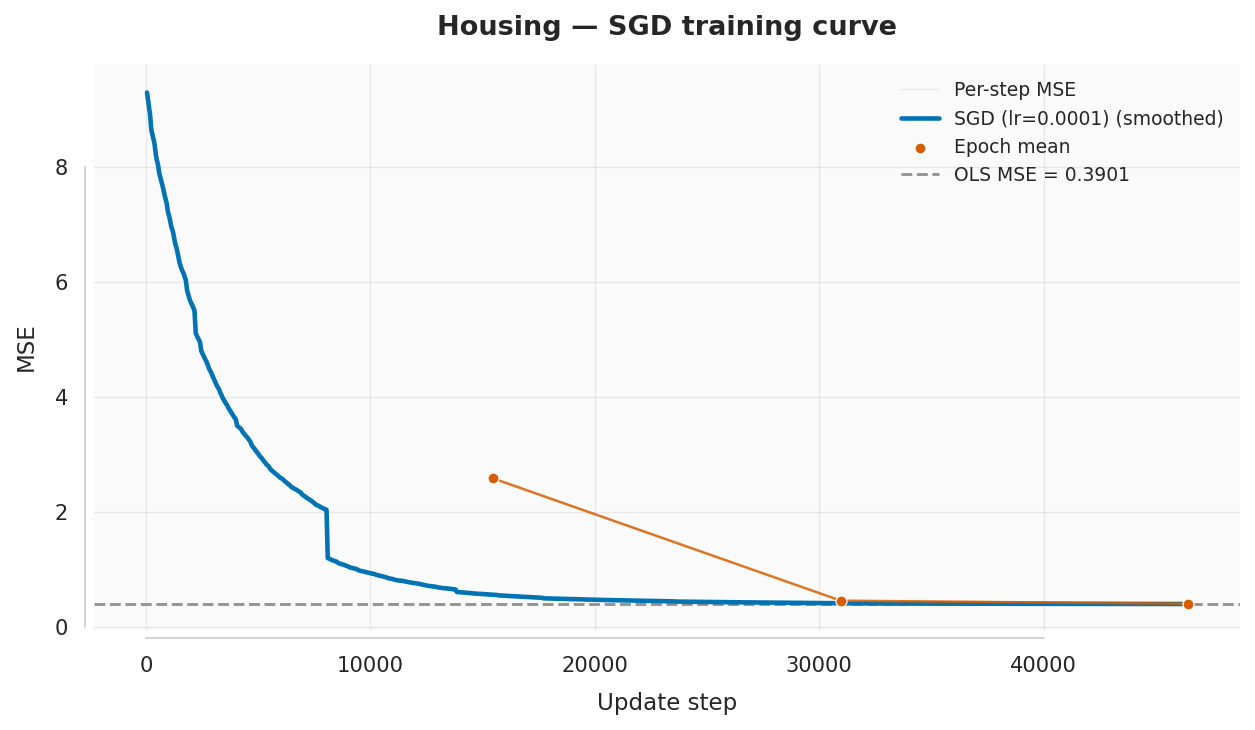

In [66]:
lr = 0.0001
W_sgd, train_loss = train(housing_train, housing_target_train, lr=lr, num_epochs=3)
ols_mse = mse(housing_target_train, np.hstack((housing_train,np.ones((housing_train.shape[0],1)))) @ W_housing_ols_with_intercept)

visualize_train_loss(
    train_loss,
    lr=lr,
    ols_mse=ols_mse,
    n_samples=housing_train.shape[0],
    smooth_window=50,
    title="Housing — SGD training curve",
)

(<Figure size 1275x750 with 1 Axes>,
 <Axes: title={'center': 'Diabetes — SGD training curve'}, xlabel='Update step', ylabel='MSE'>)

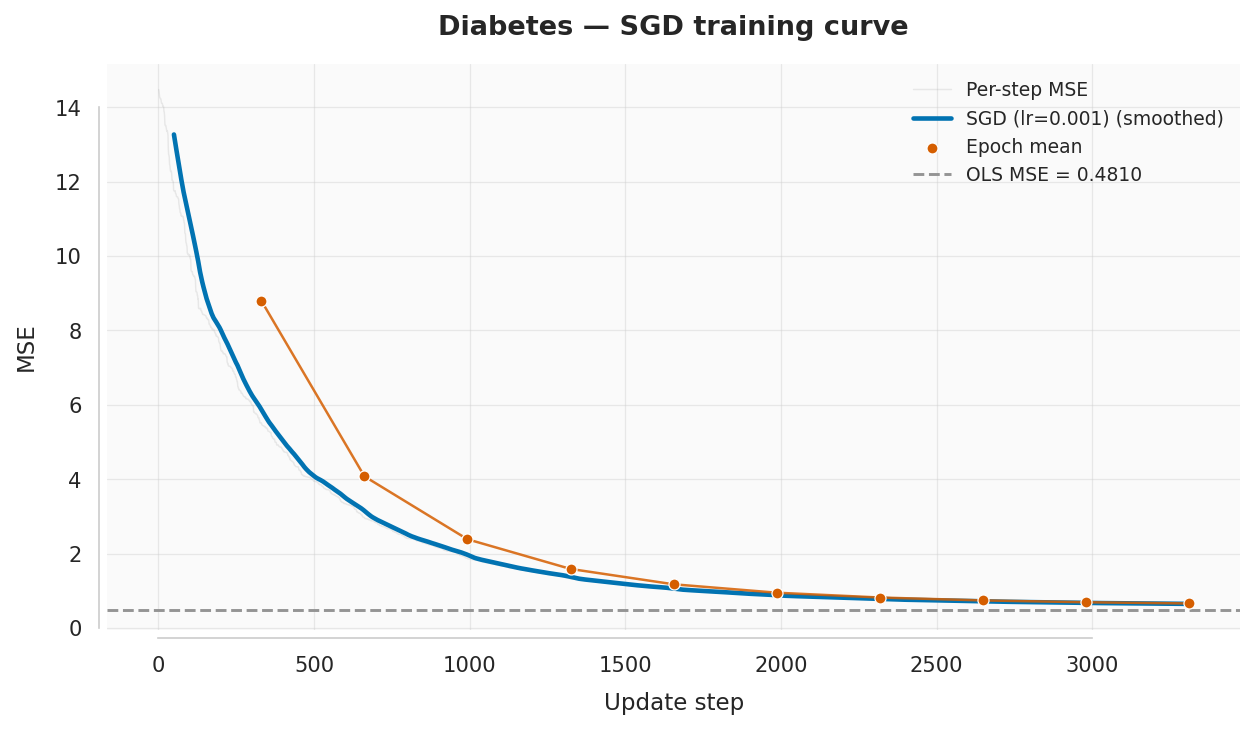

In [72]:
lr = 0.001
W_sgd, train_loss = train(diabetes_train, diabetes_target_train, lr=lr, num_epochs=10)
ols_mse = mse(diabetes_target_train, np.hstack((diabetes_train,np.ones((diabetes_train.shape[0],1)))) @ W_diabetes_ols_with_intercept)

visualize_train_loss(
    train_loss,
    lr=lr,
    ols_mse=ols_mse,
    n_samples=diabetes_train.shape[0],
    smooth_window=50,
    title="Diabetes — SGD training curve",
)